# AC 209B Final Project — Milestone 3

**Canvas Project Number:** 100  
**Group Members:** Kaiyuan Huang, Gefei Shen, Krystal Qiu, Jiangqi Wu, Tom Tan

---

## Project Overview

**Research Question:** Can financial news headlines, when combined with recent stock market data, improve the prediction of short-term stock volatility?

**Target Variable:** Next-day realized volatility computed using the Garman-Klass estimator on t+1 OHLCV data, evaluated with MSE and RMSE.

---

## Milestone 2 Recap

### Data Pipeline
We built a multimodal dataset by combining two sources: financial news headlines (Kaggle, 2009–2020) tagged with stock tickers, and daily OHLCV price data fetched via yfinance. Starting from ~849K rows across 3,580 tickers, we filtered out ETFs and mutual funds, leaving 2,122 individual equities. For each headline, we aligned 10 days of historical OHLCV features (t−1 to t−10, 50 columns) and one day of forward OHLCV values (t+1, 5 columns), then joined sector and industry metadata from yfinance. The final dataset had **650,985 rows × 61 columns**, spanning July 2010 to June 2020 across 11 sectors.

### EDA Findings
- Volatility is **persistent** — past volatility strongly predicts future volatility; this is our strongest baseline signal
- Clear **sector differences** — Energy & Basic Materials most volatile, Utilities & Consumer Defensive lowest; sector is a useful feature
- **COVID-19 spike** (Mar 2020): 7× the baseline, confirming we need a time-based train/test split
- **Simple text signals are weak** — neither TextBlob sentiment nor raw news volume showed a clear relationship with next-day volatility

---

## Milestone 3 — What Changed

Before modeling, we identified and fixed three issues carried over from Milestone 2:

1. **Duplicate targets** — multiple headlines for the same stock on the same day all shared identical OHLCV features and target values, inflating row count and overweighting high-news days. Fixed by collapsing to one row per stock per day (concatenating titles with `";"`).
2. **Data leakage** — the `t_plus_1_*` columns used to compute GK volatility were still present in the feature set. Fixed by dropping all `t_plus_1_*` columns after computing the target.
3. **Skewed target distribution** — raw GK volatility is heavily right-skewed. Fixed by adding `log_gk_volatility = log(gk_volatility)` as the primary regression target.

Part 0 below performs these fixes. All modeling in Milestone 3 uses the cleaned output: `expanded_equities_merged_day_gk_hist.parquet`.

# Part 0: Further Preprocessing

In Milestone 2, we built the base dataset (`expanded_equities.parquet`) by aligning financial news headlines with 10-day historical OHLCV features and next-day OHLCV values. However, several issues remained:

1. **Duplicate targets** — multiple headlines for the same stock on the same day all pointed to the same next-day OHLCV values, inflating the dataset and overweighting high-news days.
2. **Data leakage** — the `t_plus_1_*` columns (which we use to compute the target) were still present in the feature set.
3. **Zero-volatility rows** — some rows had `gk_volatility == 0`, indicating no real trading occurred that day.
4. **Skewed target distribution** — raw GK volatility is heavily right-skewed, which can hurt model training.

This section addresses all four issues before any modeling begins.

## 0.1 Imports

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## 0.2 Load Data

We load `expanded_equities.parquet`, the cleaned equity-only dataset produced in Milestone 2. This file contains 650,985 rows × 81 columns, covering news headlines from 2,108 unique stocks across 11 sectors from 2010 to 2020.

Each row corresponds to **one news headline**, with 50 columns of historical OHLCV features (t−1 to t−10), 5 columns of next-day OHLCV values (t+1), and metadata columns (stock, date, title, sector, industry).

In [4]:
input_path = Path('expanded_equities.parquet')
raw_df = pd.read_parquet(input_path)

print('raw_shape =', raw_df.shape)
print('raw_columns =', len(raw_df.columns))
raw_df.head(10)

raw_shape = (650985, 61)
raw_columns = 61


,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,...,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,...,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research
2,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 16:45:00+00:00,A,https://www.benzinga.com/news/20/05/16095921/4...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 15:38:00+00:00,A,https://www.benzinga.com/news/20/05/16095304/b...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
5,"CFRA Maintains Hold on Agilent Technologies, L...",2020-05-22 15:23:00+00:00,A,https://www.benzinga.com/news/20/05/16095163/c...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
6,"UBS Maintains Neutral on Agilent Technologies,...",2020-05-22 13:36:00+00:00,A,https://www.benzinga.com/news/20/05/16094027/u...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
7,Agilent Technologies shares are trading higher...,2020-05-22 13:07:00+00:00,A,https://www.benzinga.com/wiim/20/05/16093805/a...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
8,Wells Fargo Maintains Overweight on Agilent Te...,2020-05-22 12:37:00+00:00,A,https://www.benzinga.com/news/20/05/16093505/w...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
9,10 Biggest Price Target Changes For Friday,2020-05-22 12:06:00+00:00,A,https://www.benzinga.com/analyst-ratings/price...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research


## 0.3 Merge by Stock + Day (Fix Duplicate Target Problem)

In Milestone 2, the dataset was **news-centric**: one row per headline. This means that if Apple had 3 headlines on 2019-10-30, there would be 3 rows all sharing the exact same OHLCV features and the same next-day volatility target. This causes two problems:
- The model sees the same target multiple times, biasing it toward high-news days.
- Random train/test splitting could put the same stock+day in both splits, causing data leakage.

We fix this by collapsing to **one row per stock per day**:
- All headlines for the same stock+day are concatenated into a single `title` string, separated by `";"`. This preserves all text information without duplication.
- All OHLCV feature columns take the `first` value (they are identical across duplicate rows anyway).
- The `url` column is dropped as it is not used in modeling.

In [5]:
# merge by stock + day (ignore intraday timestamp)
tmp = raw_df.copy()
tmp['date_ts'] = pd.to_datetime(tmp['date'], utc=True, errors='coerce')
tmp['date_day'] = tmp['date_ts'].dt.floor('D').dt.tz_localize(None)

KEY_COLS = ['stock', 'date_day']
EXCLUDE_COLS = {'title', 'url', 'date', 'date_ts', 'date_day'}
value_cols = [c for c in tmp.columns if c not in EXCLUDE_COLS]

def join_unique_titles(series: pd.Series) -> str:
    vals = pd.unique(series.dropna().astype(str))
    return '; '.join(vals)

agg_map = {c: 'first' for c in value_cols}
agg_map['title'] = join_unique_titles

merged_df = tmp.groupby(KEY_COLS, as_index=False, sort=False).agg(agg_map)
merged_df = merged_df.rename(columns={'date_day': 'date'})

ordered = ['date', 'stock', 'title'] + [c for c in raw_df.columns if c not in {'date', 'stock', 'title', 'url'}]
eda_df = merged_df[[c for c in ordered if c in merged_df.columns]].copy()

print('merged_shape =', eda_df.shape)
print('rows_removed =', raw_df.shape[0] - eda_df.shape[0])
print('has_url =', 'url' in eda_df.columns)
print('duplicate_keys_after_merge(stock+day) =', int(eda_df.duplicated(['stock', 'date']).sum()))
eda_df.head(10)

merged_shape = (381047, 60)
rows_removed = 269938
has_url = False
duplicate_keys_after_merge(stock+day) = 0


,date,stock,title,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,2020-06-05,A,Stocks That Hit 52-Week Highs On Friday,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,91.139999,...,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research
1,2020-06-03,A,Stocks That Hit 52-Week Highs On Wednesday,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,89.980003,...,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research
2,2020-05-26,A,71 Biggest Movers From Friday,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,82.190002,...,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research
3,2020-05-22,A,46 Stocks Moving In Friday's Mid-Day Session; ...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,82.980003,...,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0,Healthcare,Diagnostics & Research
4,2020-05-21,A,8 Stocks Moving In Thursday's After-Hours Sess...,82.980003,82.980003,81.470001,81.709999,2748100.0,83.230003,83.540001,...,77.540001,78.500000,1190600.0,85.000000,87.669998,84.199997,84.980003,5063100.0,Healthcare,Diagnostics & Research
5,2020-05-18,A,Agilent Technologies Receives FDA Approval for...,81.510002,82.830002,81.220001,81.589996,4529400.0,79.290001,81.660004,...,73.419998,74.559998,1555400.0,83.230003,83.540001,81.889999,81.970001,2099200.0,Healthcare,Diagnostics & Research
6,2020-05-16,A,"Q1 13F Roundup: How Buffett, Einhorn, Ackman A...",81.510002,82.830002,81.220001,81.589996,4529400.0,79.290001,81.660004,...,73.419998,74.559998,1555400.0,83.239998,84.389999,82.290001,83.660004,2076000.0,Healthcare,Diagnostics & Research
7,2020-05-15,A,Pershing Square 13F Shows Fund Raises Stake In...,79.290001,81.660004,78.720001,81.639999,2285900.0,80.379997,81.930000,...,73.570000,74.209999,1618600.0,83.239998,84.389999,82.290001,83.660004,2076000.0,Healthcare,Diagnostics & Research
8,2020-05-08,A,How Bill Ackman Successfully Navigated Coronav...,78.769997,79.330002,77.540001,78.500000,1190600.0,76.690002,78.830002,...,74.019997,75.750000,1654300.0,79.599998,81.989998,79.500000,81.269997,1691600.0,Healthcare,Diagnostics & Research
9,2020-05-05,A,Shares of several healthcare companies are tra...,74.279999,74.620003,73.419998,74.559998,1555400.0,75.550003,76.099998,...,73.709999,73.750000,2848100.0,76.690002,78.830002,76.650002,77.870003,2303600.0,Healthcare,Diagnostics & Research


## 0.4 Compute GK Volatility (Target Variable)

We compute next-day realized volatility using the **Garman-Klass (GK) estimator**, which uses the full intraday price bar (Open, High, Low, Close) from day t+1:

$$\sigma^2_{GK} = \frac{1}{2}\left(\ln\frac{H}{L}\right)^2 - (2\ln 2 - 1)\left(\ln\frac{C}{O}\right)^2$$

This estimator is more statistically efficient than simple close-to-close return variance because it incorporates the intraday High-Low range. The result is stored as `gk_volatility` and serves as our regression target **y**.

Any rows where one of O/H/L/C is zero or negative (indicating bad data) are masked as `NaN`.

In [6]:
# compute GK variance (sigma^2)
o = pd.to_numeric(eda_df['t_plus_1_open'],  errors='coerce')
h = pd.to_numeric(eda_df['t_plus_1_high'],  errors='coerce')
l = pd.to_numeric(eda_df['t_plus_1_low'],   errors='coerce')
c = pd.to_numeric(eda_df['t_plus_1_close'], errors='coerce')

invalid = (o <= 0) | (h <= 0) | (l <= 0) | (c <= 0)
gk_sigma2 = 0.5 * (np.log(h / l) ** 2) - (2 * np.log(2) - 1) * (np.log(c / o) ** 2)
eda_df['gk_volatility'] = gk_sigma2.mask(invalid, np.nan)

print('gk_volatility null_count =', int(eda_df['gk_volatility'].isna().sum()))
eda_df['gk_volatility'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

gk_volatility null_count = 0


count    381047.000000
mean          0.001252
std           0.007451
min           0.000000
1%            0.000012
5%            0.000032
50%           0.000265
95%           0.004474
99%           0.015339
max           1.019725
Name: gk_volatility, dtype: float64

## 0.5 Inspect Zero-Volatility Rows

Rows where `gk_volatility == 0` indicate days where the stock's Open, High, Low, and Close were all identical — meaning no real price movement occurred. This typically happens when a stock was halted, had no trading activity, or had stale/erroneous data in the cache. These rows carry no meaningful signal for volatility prediction and are removed in the next step.

In [7]:
eda_df[eda_df['gk_volatility'] == 0].head(10)

,date,stock,title,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,...,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,gk_volatility
421,2019-05-13,AAME,Atlantic American Q1 EPS $0.19 Up From $(0.25)...,2.510000,2.510000,2.480000,2.490000,1100.0,2.350000,2.350000,...,2.360000,200.0,2.450000,2.450000,2.450000,2.450000,100.0,Financial Services,Insurance - Life,0.0
426,2018-08-08,AAME,"Stocks Which Set New 52-Week Low Yesterday, Au...",2.360000,2.600000,2.200000,2.500000,9300.0,2.650000,2.650000,...,2.400000,1000.0,2.500000,2.500000,2.500000,2.500000,100.0,Financial Services,Insurance - Life,0.0
428,2018-03-26,AAME,Atlantic American Q4 EPS $0.12 vs $0.06 In Sam...,3.130000,3.250000,3.100000,3.250000,1100.0,3.100000,3.250000,...,3.430000,3300.0,3.250000,3.250000,3.250000,3.250000,0.0,Financial Services,Insurance - Life,0.0
433,2016-11-14,AAME,Atlantic American Reports Q3 EPS $0.00 vs. Pri...,3.600000,3.650000,3.500000,3.650000,1200.0,3.600000,3.700000,...,4.050000,4000.0,3.700000,3.700000,3.700000,3.700000,0.0,Financial Services,Insurance - Life,0.0
434,2016-08-11,AAME,Atlantic American Reports Q2 EPS $0.01 vs $0.1...,4.100000,4.150000,4.100000,4.100000,800.0,4.100000,4.160000,...,4.200000,700.0,4.060000,4.060000,4.060000,4.060000,0.0,Financial Services,Insurance - Life,0.0
435,2016-05-12,AAME,Atlantic American Reports Q1 EPS $0.04 vs $0.0...,3.950000,3.950000,3.950000,3.950000,400.0,4.100000,4.100000,...,4.310000,3700.0,3.870000,3.870000,3.870000,3.870000,100.0,Financial Services,Insurance - Life,0.0
460,2011-03-01,AAME,Atlantic American Corporation Announces Specia...,2.030000,2.040000,2.030000,2.040000,1500.0,2.040000,2.040000,...,2.100000,3400.0,2.090000,2.090000,2.090000,2.090000,100.0,Financial Services,Insurance - Life,0.0
2417,2016-03-28,ACAD,Mid-Afternoon Market Update: Dow Jumps 50 Poin...,20.280001,21.040001,19.320000,20.309999,2319000.0,22.610001,23.299999,...,20.190001,1742500.0,23.809999,23.809999,23.809999,23.809999,1200000.0,Healthcare,Biotechnology,0.0
5045,2018-04-20,ACU,Acme United Sees FY18 Sales Of ~$140M vs $139....,22.090000,22.090000,21.629999,21.750000,2300.0,22.090000,22.090000,...,22.100000,1200.0,21.860001,21.860001,21.860001,21.860001,800.0,Consumer Defensive,Household & Personal Products,0.0
5065,2015-04-10,ACU,Top 4 Stocks In The Housewares & Accessories I...,18.600000,18.889999,18.600000,18.799999,600.0,18.330000,18.900000,...,18.260000,1600.0,18.600000,18.600000,18.600000,18.600000,800.0,Consumer Defensive,Household & Personal Products,0.0


## 0.6 Drop t+1 Columns to Prevent Data Leakage

The `t_plus_1_*` columns (Open, High, Low, Close, Volume for the next trading day) were used to compute `gk_volatility`, but they **must not be kept as input features**. If the model had access to next-day prices during training, it would trivially learn to predict volatility without using any real signal — this is a severe form of data leakage.

After dropping these 5 columns, the remaining feature set is:
- 50 historical OHLCV columns (t−1 to t−10) — model inputs
- `gk_volatility` — prediction target
- `title`, `stock`, `date`, `sector`, `industry` — metadata / categorical features

In [8]:
# drop all t+1 OHLCV columns to prevent leakage
leak_cols = [c for c in eda_df.columns if c.startswith('t_plus_1_')]
eda_df = eda_df.drop(columns=leak_cols)

print('dropped_t_plus_1_cols =', leak_cols)
print('remaining_columns =', len(eda_df.columns))

dropped_t_plus_1_cols = ['t_plus_1_open', 't_plus_1_high', 't_plus_1_low', 't_plus_1_close', 't_plus_1_volume']
remaining_columns = 56


## 0.7 Remove Zero-Volatility Rows and Compute Log Volatility

We remove all rows where `gk_volatility == 0` for the reasons described in 0.5.

We then compute `log_gk_volatility = log(gk_volatility)` as an alternative target. Raw GK volatility is heavily right-skewed (a few extreme events like COVID-19 dominate), which can make regression harder. Taking the log compresses the scale and produces a more symmetric, approximately normal distribution — this is standard practice in financial volatility modeling and typically leads to better-behaved loss surfaces during training.

In [9]:
# keep only non-zero gk_volatility rows, then compute log_gk_volatility
eda_df['date'] = pd.to_datetime(eda_df['date'], errors='coerce')

rows_before = len(eda_df)
zero_rows   = int((eda_df['gk_volatility'] == 0).sum())
eda_df      = eda_df.loc[eda_df['gk_volatility'] != 0].copy()
rows_after  = len(eda_df)

eda_df['log_gk_volatility'] = np.log(eda_df['gk_volatility'])

print('rows_before_filter =', rows_before)
print('zero_gk_rows_removed =', zero_rows)
print('rows_after_filter  =', rows_after)

inspect_cols = ['date', 'stock', 'gk_volatility', 'log_gk_volatility']
eda_df[inspect_cols].head(10)

rows_before_filter = 381047
zero_gk_rows_removed = 1256
rows_after_filter  = 379791


,date,stock,gk_volatility,log_gk_volatility
0,2020-06-05,A,0.000099,-9.219757
1,2020-06-03,A,0.000141,-8.863505
2,2020-05-26,A,0.000304,-8.097401
3,2020-05-22,A,0.000088,-9.333144
4,2020-05-21,A,0.000815,-7.111774
5,2020-05-18,A,0.000109,-9.123393
6,2020-05-16,A,0.000308,-8.086330
7,2020-05-15,A,0.000308,-8.086330
8,2020-05-08,A,0.000309,-8.082070
9,2020-05-05,A,0.000303,-8.101227


## 0.8 Distribution of GK Volatility

We plot the histogram of raw `gk_volatility` to confirm the right-skewed distribution. The vast majority of values cluster near zero, with a long tail of extreme events. This motivates the log transformation applied above.

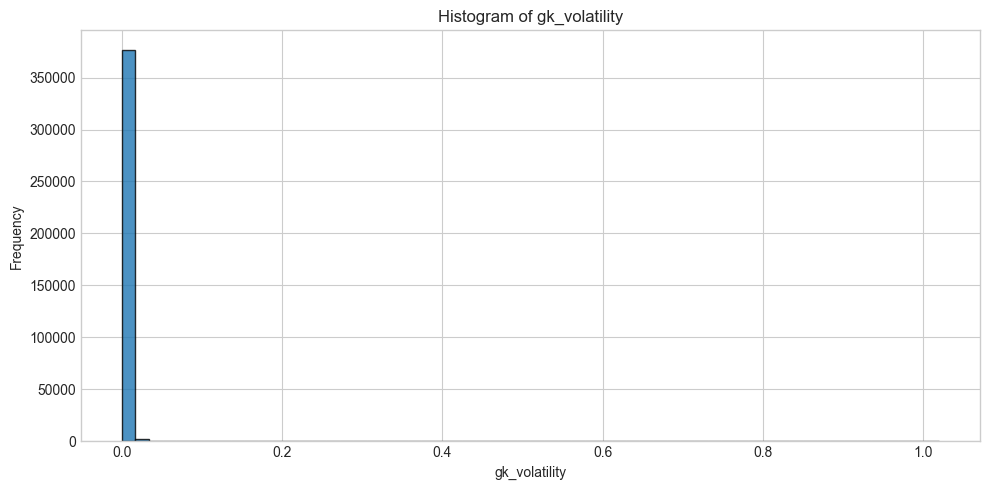

In [10]:
# histogram: row-level gk_volatility
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eda_df['gk_volatility'].dropna(), bins=60, edgecolor='black', alpha=0.8)
ax.set_title('Histogram of gk_volatility')
ax.set_xlabel('gk_volatility')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 0.9 Distribution of Log GK Volatility

After the log transformation, the distribution becomes approximately symmetric and bell-shaped — much closer to normal. This is the version of the target we will use for model training, as it produces more stable gradients and avoids the model being dominated by extreme outlier events.

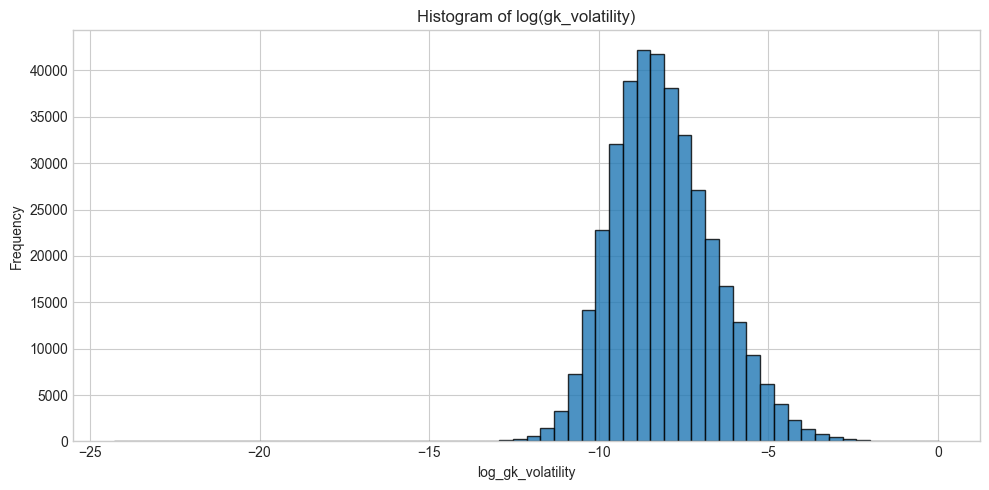

count    379791.000000
mean         -8.094679
std           1.512999
min         -24.277591
25%          -9.156578
50%          -8.230667
75%          -7.149187
max           0.019533
Name: log_gk_volatility, dtype: float64

In [11]:
# histogram: row-level log_gk_volatility
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eda_df['log_gk_volatility'].dropna(), bins=60, edgecolor='black', alpha=0.8)
ax.set_title('Histogram of log(gk_volatility)')
ax.set_xlabel('log_gk_volatility')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

eda_df['log_gk_volatility'].describe()

## 0.10 Volatility Over Time (Post-Merge)

We create `visualize_df`, a lightweight 3-column subset of `eda_df` containing only `date`, `gk_volatility`, and `log_gk_volatility`. This is used purely for time series visualization — carrying all 80+ columns into plotting is unnecessary.

We plot **median monthly GK volatility** to observe how volatility evolves across the 2010–2020 period. Unlike Milestone 2, this plot is computed on the **deduplicated dataset** (one row per stock+day), so each stock+day contributes equally to the median regardless of how many headlines it had.

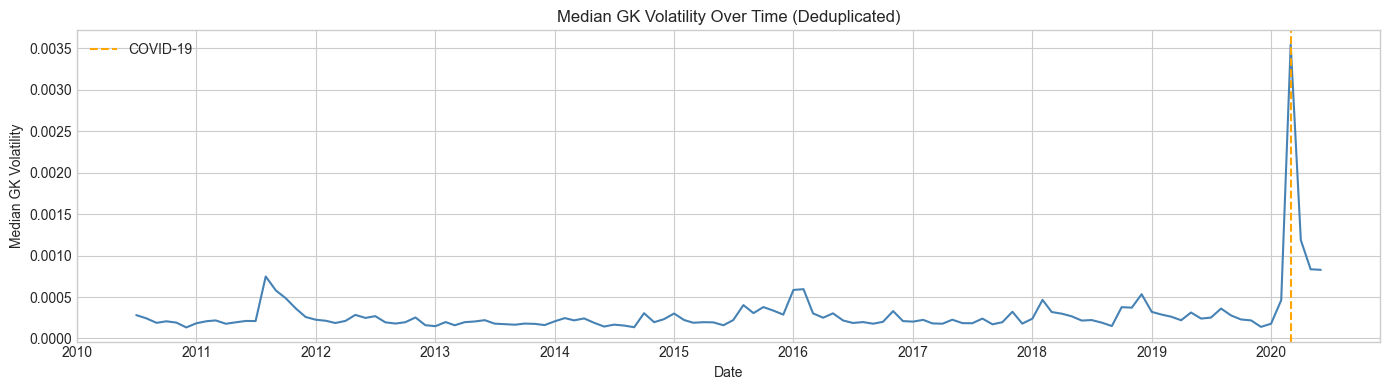

In [12]:
visualize_df = eda_df[['date', 'gk_volatility', 'log_gk_volatility']].copy()

visualize_df['date']  = pd.to_datetime(visualize_df['date'])
visualize_df['year']  = visualize_df['date'].dt.year
visualize_df['month'] = visualize_df['date'].dt.to_period('M')

monthly_vol = visualize_df.groupby('month')['gk_volatility'].median().reset_index()
monthly_vol['month'] = monthly_vol['month'].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(monthly_vol['month'], monthly_vol['gk_volatility'], color='steelblue')
plt.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', label='COVID-19')
plt.title('Median GK Volatility Over Time (Deduplicated)')
plt.xlabel('Date')
plt.ylabel('Median GK Volatility')
plt.legend()
plt.tight_layout()
plt.show()

## 0.11 Log Volatility Over Time

The same time series plotted in log scale. The COVID-19 spike is still clearly visible but is no longer as extreme relative to the baseline, illustrating how the log transformation brings outlier events into a more comparable range with normal market conditions. This confirms that `log_gk_volatility` is a more suitable regression target than raw `gk_volatility`.

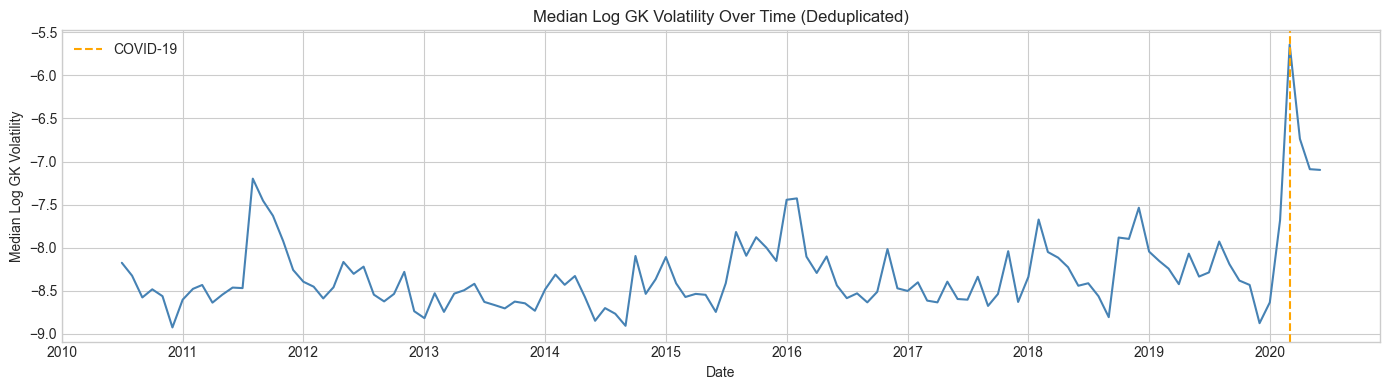

In [13]:
monthly_log_vol = visualize_df.groupby('month')['log_gk_volatility'].median().reset_index()
monthly_log_vol['month'] = monthly_log_vol['month'].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(monthly_log_vol['month'], monthly_log_vol['log_gk_volatility'], color='steelblue')
plt.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', label='COVID-19')
plt.title('Median Log GK Volatility Over Time (Deduplicated)')
plt.xlabel('Date')
plt.ylabel('Median Log GK Volatility')
plt.legend()
plt.tight_layout()
plt.show()

## 0.12 Save Preprocessed Dataset

We save the cleaned, deduplicated dataset as `expanded_equities_merged_day_gk_hist.parquet`. This is the **starting point for all modeling in Milestone 3** — do not use the original `expanded_equities.parquet` for any further analysis, as it still contains the issues fixed in this section.

Final dataset properties:
- One row per stock per trading day
- No duplicate targets
- No t+1 leakage columns
- No zero-volatility rows
- Both `gk_volatility` and `log_gk_volatility` available as target options

In [14]:
# save row-level output
row_output_path = Path('../expanded_equities_merged_day_gk_hist.parquet')

eda_save = eda_df.copy()
eda_save.to_parquet(row_output_path, index=False)

print('saved:', row_output_path.resolve())
print('final shape:', eda_save.shape)

saved: /Users/jingxiaoqiu/Desktop/expanded_equities_merged_day_gk_hist.parquet
final shape: (379791, 57)


# Part 1: EDA & Feature Engineering

## 1.1 TF-IDF Analysis: High vs Low Volatility Headlines

We redo the TF-IDF analysis on the deduplicated dataset (one row per stock per day) to identify which words and phrases are most associated with high vs low next-day volatility. Headlines are split at the **75th percentile** of `log_gk_volatility`. Unlike Milestone 2, the merged `title` field may contain multiple concatenated headlines for the same stock+day, giving a richer text signal per observation.

threshold (75th pct): -7.1492
high vol rows: 94,948
low vol rows:  284,843


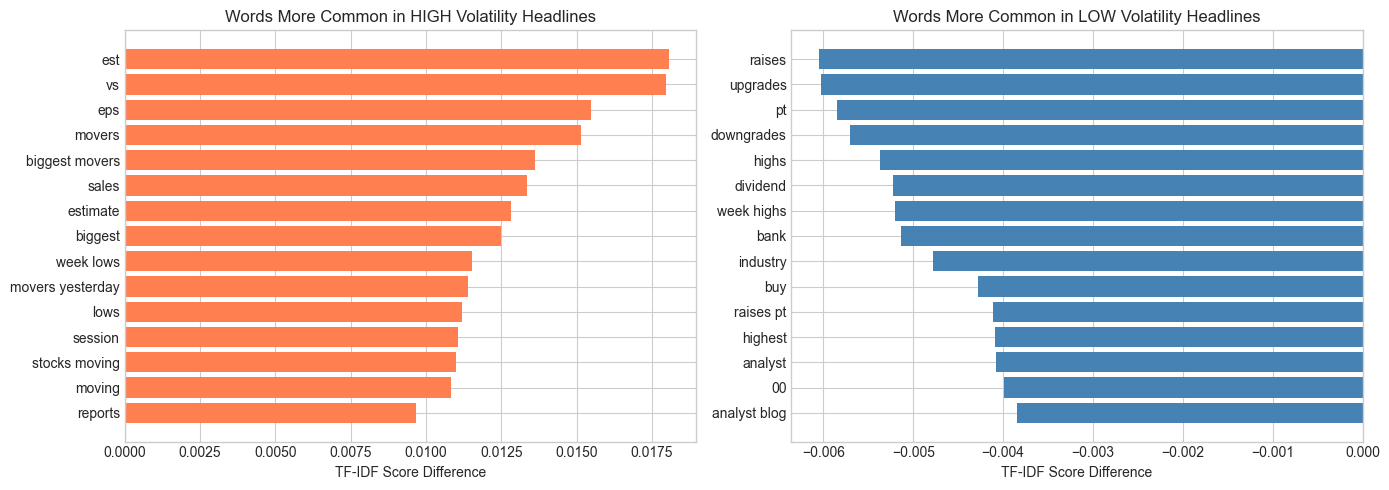

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# split into high and low volatility groups
threshold = eda_df['log_gk_volatility'].quantile(0.75)
high_vol_titles = eda_df[eda_df['log_gk_volatility'] >= threshold]['title'].fillna('')
low_vol_titles  = eda_df[eda_df['log_gk_volatility'] <  threshold]['title'].fillna('')

print(f"threshold (75th pct): {threshold:.4f}")
print(f"high vol rows: {len(high_vol_titles):,}")
print(f"low vol rows:  {len(low_vol_titles):,}")

# fit tfidf on all titles
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
vectorizer.fit(eda_df['title'].fillna(''))

# mean tfidf score per word for each group
high_tfidf = np.asarray(vectorizer.transform(high_vol_titles).mean(axis=0)).flatten()
low_tfidf  = np.asarray(vectorizer.transform(low_vol_titles).mean(axis=0)).flatten()

features = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame({
    'word': features,
    'high_vol_score': high_tfidf,
    'low_vol_score':  low_tfidf,
})
tfidf_df['diff'] = tfidf_df['high_vol_score'] - tfidf_df['low_vol_score']

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_high = tfidf_df.nlargest(15, 'diff')
axes[0].barh(top_high['word'], top_high['diff'], color='coral')
axes[0].set_title('Words More Common in HIGH Volatility Headlines')
axes[0].set_xlabel('TF-IDF Score Difference')
axes[0].invert_yaxis()

top_low = tfidf_df.nsmallest(15, 'diff')
axes[1].barh(top_low['word'], top_low['diff'], color='steelblue')
axes[1].set_title('Words More Common in LOW Volatility Headlines')
axes[1].set_xlabel('TF-IDF Score Difference')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretation:** The TF-IDF analysis reveals a clear semantic separation between high and low volatility headlines. On the high volatility side, the most distinctive signal comes from earnings-related language, particularly "eps", "movers", and "biggest movers". These terms are strongly associated with earnings surprise events and large intraday price movements, which are among the most well-known drivers of short-term stock volatility. Other terms like "est" and "vs" also appear frequently, though they are less specific and may reflect general comparison language in financial headlines.

On the low volatility side, terms like "raises", "upgrades", "downgrades", "raises pt", and "dividend" dominate. These correspond to routine analyst actions and scheduled corporate events that markets tend to absorb without large reactions.

Critically, this distinction is semantic rather than sentiment-based. Words like "raises" and "upgrades" carry positive sentiment but are associated with low volatility, which explains why TextBlob sentiment showed no predictive power in Milestone 2. This indicates that predicting volatility from headlines requires a model that understands the financial meaning of words in context, not just their surface tone. This motivates the use of BERT as our text encoder, which captures contextual word meaning rather than relying on a fixed sentiment dictionary.

## 1.2 Market Regime Analysis: Justifying HMM as a Conditioning Signal

A key observation from Milestone 2 is that volatility is not stationary — the COVID-19 period produced spikes 7× the baseline, and other elevated periods exist throughout 2010–2020. This suggests the market operates in distinct **regimes**, where the same news headline may have very different volatility implications depending on the current market environment. We use a Hidden Markov Model (HMM) to identify these regimes from the observed volatility sequence and show that they are meaningfully separated, justifying regime as an additional input feature in our final model.

We fit the HMM on **market-level daily volatility** (median `log_gk_volatility` across all stocks per day) rather than individual stock volatility, since regime is a macro-level concept.

In [ ]:
from hmmlearn.hmm import GaussianHMM

# compute market-level daily volatility (median across all stocks per day)
market_vol = (
    eda_df.groupby('date')['log_gk_volatility']
    .median()
    .reset_index()
    .sort_values('date')
)

# fit HMM with 3 regimes on the market volatility sequence
X = market_vol['log_gk_volatility'].values.reshape(-1, 1)

hmm = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
hmm.fit(X)
market_vol['regime'] = hmm.predict(X)

# sort regimes by mean volatility so 0=low, 1=medium, 2=high
regime_means = market_vol.groupby('regime')['log_gk_volatility'].mean().sort_values()
regime_map = {old: new for new, old in enumerate(regime_means.index)}
market_vol['regime'] = market_vol['regime'].map(regime_map)
regime_names = {0: 'Normal', 1: 'High Volatility'}
market_vol['regime_label'] = market_vol['regime'].map(regime_names)

print(market_vol['regime_label'].value_counts())

regime_label
Normal             3046
High Volatility     481
Name: count, dtype: int64


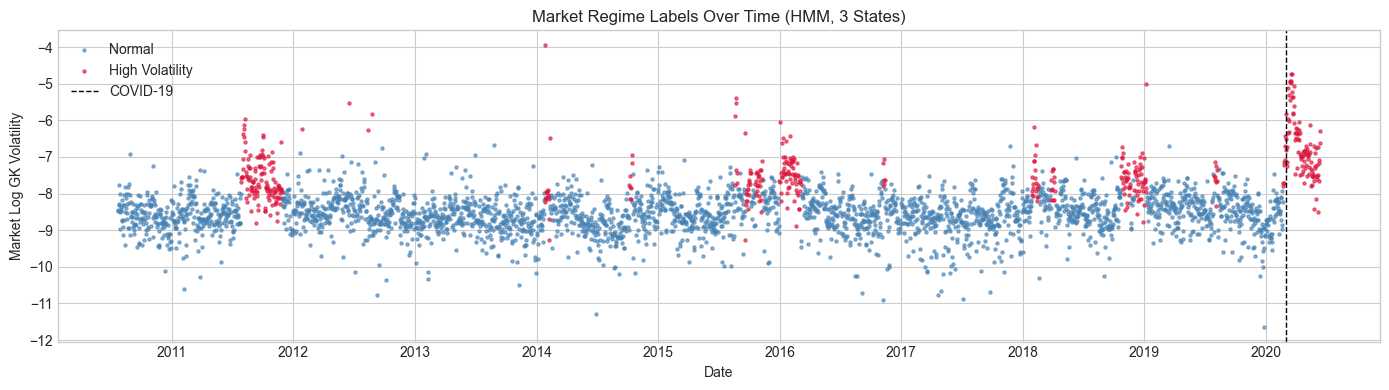

In [25]:
# plot 1: regime labels over time
fig, ax = plt.subplots(figsize=(14, 4))

colors = {0: 'steelblue', 1: 'crimson'}
for regime, group in market_vol.groupby('regime'):
    ax.scatter(group['date'], group['log_gk_volatility'],
               c=colors[regime], label=regime_names[regime], s=5, alpha=0.6)

ax.axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--', linewidth=1, label='COVID-19')
ax.set_title('Market Regime Labels Over Time (HMM, 3 States)')
ax.set_xlabel('Date')
ax.set_ylabel('Market Log GK Volatility')
ax.legend()
plt.tight_layout()
plt.show()

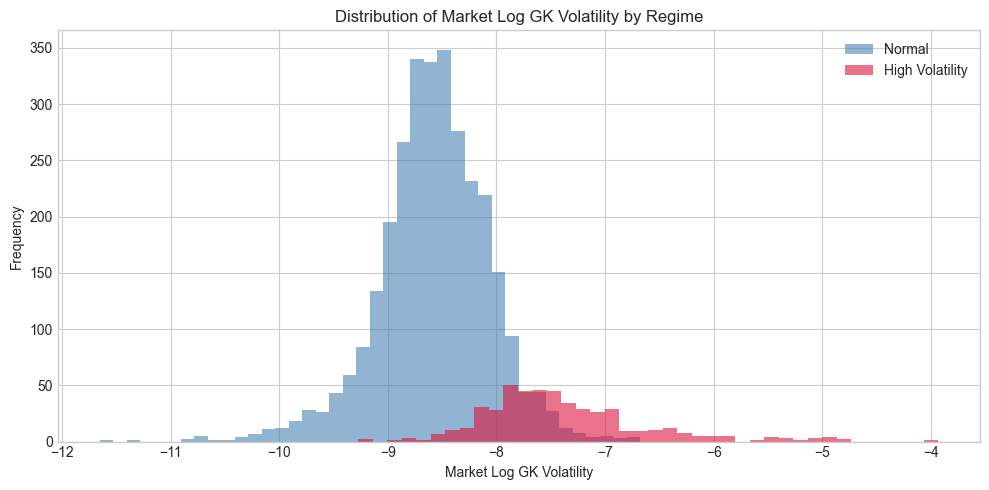

In [26]:
# plot 2: volatility distribution by regime
fig, ax = plt.subplots(figsize=(10, 5))

for regime in [0, 1]:
    vals = market_vol[market_vol['regime'] == regime]['log_gk_volatility']
    ax.hist(vals, bins=40, alpha=0.6, color=colors[regime],
            label=regime_names[regime], edgecolor='none')

ax.set_title('Distribution of Market Log GK Volatility by Regime')
ax.set_xlabel('Market Log GK Volatility')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The two plots together justify the use of HMM regime as an additional input feature in our final model. The time series plot shows that the High Volatility regime is not randomly distributed across the decade but clusters around known periods of market stress, including the European debt crisis in 2011-2012, market turbulence in 2016, the trade war period in 2018-2019, and most prominently the COVID-19 shock in March 2020. This confirms that the HMM is capturing meaningful market structure rather than noise.

The distribution plot shows that the two regimes have clearly different volatility profiles. The Normal regime centers around -9 on the log scale while the High Volatility regime centers around -8, representing a meaningful difference in actual volatility levels. Although some overlap exists between the two distributions, this is expected since market regimes do not have hard boundaries in practice.

Together, these results show that knowing which regime a given day falls into provides genuine additional information about the expected level of volatility. A single model trained on all days without regime information would need to fit both distributions simultaneously, making it harder to predict accurately in either setting. Adding the HMM regime label as a conditioning feature allows the model to adjust its predictions based on the current market environment, which is particularly important for handling extreme periods like COVID-19.

## 1.3 Train / Validation / Test Split

Since this is time-series data, we split chronologically to avoid look-ahead bias. Random splitting would allow the model to train on future data and evaluate on past data, producing unreliable performance estimates. We use the following boundaries:

- **Train:** 2010-2017 (~7 years of normal market conditions)
- **Validation:** 2018-2019 (used for hyperparameter tuning)
- **Test:** 2020 (held-out evaluation set)

Although the test set is treated as a single split during training, we note that it spans two distinct market environments: 2020 Jan-Feb (pre-COVID, near-normal conditions) and 2020 Mar-Jun (COVID-19 outbreak, extreme volatility). During model evaluation, we will report performance separately for these two periods to better understand how each model handles distribution shift.

In [36]:
# define time-based splits
train = eda_df[eda_df['date'] < '2018-01-01']
val   = eda_df[(eda_df['date'] >= '2018-01-01') & (eda_df['date'] < '2020-01-01')]
test  = eda_df[eda_df['date'] >= '2020-01-01']

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"{name:6}: {len(split):,} rows  ({split['date'].min().date()} to {split['date'].max().date()})")

total = len(eda_df)
print(f"\ntrain: {len(train)/total*100:.1f}%  val: {len(val)/total*100:.1f}%  test: {len(test)/total*100:.1f}%")

Train : 245,181 rows  (2010-07-24 to 2017-12-31)
Val   : 95,748 rows  (2018-01-01 to 2019-12-31)
Test  : 38,862 rows  (2020-01-01 to 2020-06-11)

train: 64.6%  val: 25.2%  test: 10.2%


In [37]:
# show the two sub-periods within test
test_normal = test[test['date'] < '2020-03-01']
test_covid  = test[test['date'] >= '2020-03-01']
print(f"test_normal (pre-COVID):  {len(test_normal):,} rows  ({test_normal['date'].min().date()} to {test_normal['date'].max().date()})")
print(f"test_covid  (COVID):      {len(test_covid):,} rows  ({test_covid['date'].min().date()} to {test_covid['date'].max().date()})")

test_normal (pre-COVID):  12,239 rows  (2020-01-01 to 2020-02-29)
test_covid  (COVID):      26,623 rows  (2020-03-01 to 2020-06-11)


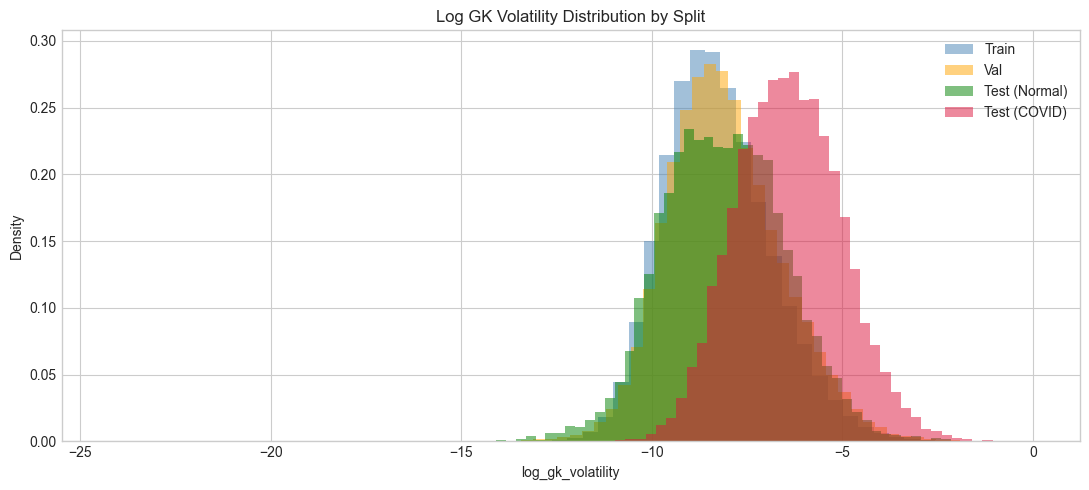

In [38]:
# plot volatility distribution across splits
fig, ax = plt.subplots(figsize=(11, 5))

colors = {'Train': 'steelblue', 'Val': 'orange', 'Test (Normal)': 'green', 'Test (COVID)': 'crimson'}
for label, split in [('Train', train), ('Val', val), ('Test (Normal)', test_normal), ('Test (COVID)', test_covid)]:
    ax.hist(split['log_gk_volatility'].dropna(), bins=60, alpha=0.5,
            color=colors[label], label=label, edgecolor='none', density=True)

ax.set_title('Log GK Volatility Distribution by Split')
ax.set_xlabel('log_gk_volatility')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# summary statistics
split_stats = pd.DataFrame({
    'Train':         train['log_gk_volatility'].describe(),
    'Val':           val['log_gk_volatility'].describe(),
    'Test (Normal)': test_normal['log_gk_volatility'].describe(),
    'Test (COVID)':  test_covid['log_gk_volatility'].describe(),
}).round(4)
print(split_stats)

             Train         Val  Test (Normal)  Test (COVID)
count  245181.0000  95748.0000     12239.0000    26623.0000
mean       -8.2797     -8.0834        -8.1205       -6.4192
std         1.4076      1.5058         1.6105        1.3924
min       -24.2776    -19.2089       -16.6833      -16.0544
25%        -9.2622     -9.1151        -9.2506       -7.3922
50%        -8.3981     -8.2025        -8.1449       -6.4397
75%        -7.4100     -7.1503        -7.0185       -5.4821
max        -0.1635      0.0195        -1.1225        0.0138


**Interpretation:** The train and validation distributions are closely aligned, confirming that the validation set is representative of training conditions. The two test sub-periods show clearly different volatility profiles: test_normal is close to the train distribution, while test_covid is shifted toward significantly higher volatility values, reflecting the COVID-19 market shock. Reporting evaluation results separately for these two periods will allow us to distinguish between a model's ability to generalize to unseen normal conditions versus its robustness under extreme distribution shift.